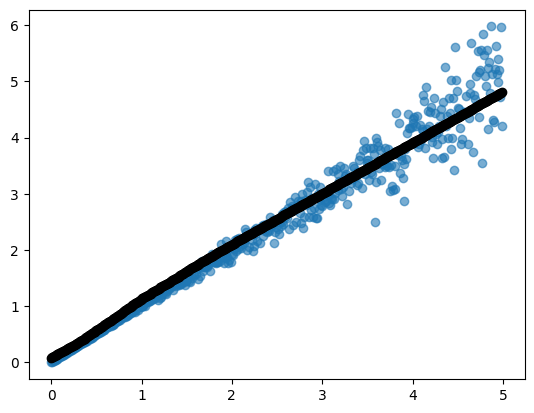

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, il=1, ol=1):
        super().__init__()
        self.l1 = nn.Linear(il, 100)
        self.l2 = nn.Linear(100, ol)
        
    def forward(self, x):
        x = torch.relu(self.l1(x))
        x = self.l2(x)
        return x

xs = torch.arange(0, 5, 0.01)
ys = torch.tensor([x * np.random.normal(loc=1, scale=x / 40) for x in xs])

model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for _ in range(100):
    optimizer.zero_grad()
    
    prediction = model(xs.view(-1, 1))
    loss = criterion(prediction, ys.view(-1, 1))

    loss.backward()
    optimizer.step()

plt.plot(xs, model(xs.view(-1, 1)).detach(), 'o', color='black')
plt.scatter(xs, ys, alpha=0.6);

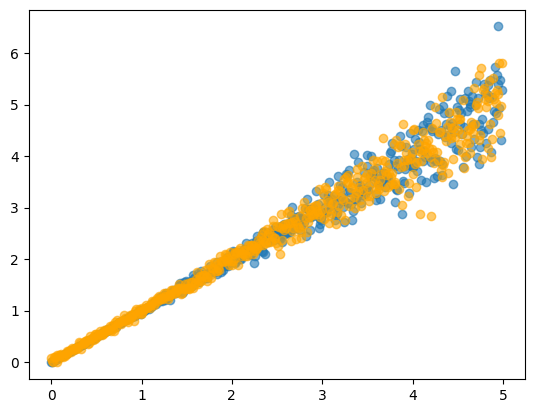

In [5]:
class MLP_g(nn.Module):
    def __init__(self, il=1, ol=1):
        super().__init__()
        self.l1 = nn.Linear(il, 100)
        self.l2 = nn.Linear(100, 100)
        
        self.mu = nn.Linear(100, ol)
        self.logstd = nn.Linear(100, ol)
        
    def forward(self, x):
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))

        mu = self.mu(x)
        logstd = self.logstd(x)
        return mu, torch.exp(logstd)

    def sample(self, x):
        mean, std = self.forward(x)
        normals = torch.distributions.Normal(mean, std)
        samples = normals.sample()
        return samples

model = MLP_g()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for _ in range(100):
    mean, std = model(xs.view(-1, 1))
    distribution = torch.distributions.Normal(mean, std)
    log_probs = distribution.log_prob(ys.view(-1, 1))
    loss = -log_probs.mean()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

plt.plot(xs, model.sample(xs.view(-1, 1)), 'o', alpha=0.6, color='orange')
plt.scatter(xs, ys, alpha=0.6);

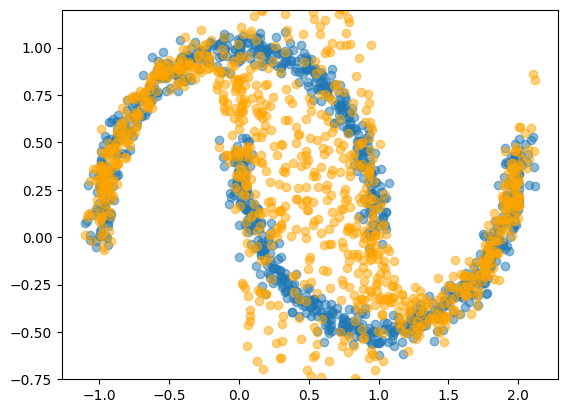

In [15]:
from sklearn.datasets import make_moons

X_moons, Y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
x_moons = torch.tensor(X_moons[:, 0]).float()
y_moons = torch.tensor(X_moons[:, 1]).float()

model = MLP_g()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for _ in range(500):
    mean, std = model(x_moons.view(-1, 1))
    distribution = torch.distributions.Normal(mean, std)
    log_probs = distribution.log_prob(y_moons.view(-1, 1))
    loss = -log_probs.mean()

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

plt.ylim(-0.75, 1.2)
plt.plot(x_moons, model.sample(x_moons.view(-1, 1)), 'o', alpha=0.5, color='orange')
plt.scatter(x=x_moons, y=y_moons, alpha=0.5);

In [7]:
class MDN(nn.Module):
    def __init__(self, il=1, gaussians=2):
        super().__init__()
        self.l1 = nn.Linear(il, 100)
        self.l2 = nn.Linear(100, 100)
        
        self.mu = nn.Linear(100, gaussians)
        self.logstd = nn.Linear(100, gaussians)
        self.weights = nn.Linear(100, gaussians)
        
    def forward(self, x):
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))

        mu = self.mu(x)
        logstd = self.logstd(x)
        weights = F.softmax(self.weights(x), dim=1)
        return mu, torch.exp(logstd), weights

    def sample(self, x):
        mean, std, weights = self.forward(x)
        normals = torch.distributions.Normal(mean, std)
        cat = torch.distributions.Categorical(weights)
        
        samples = normals.sample()
        components = cat.sample()
        
        samples = samples.gather(1, components.unsqueeze(1))
        return samples, cat

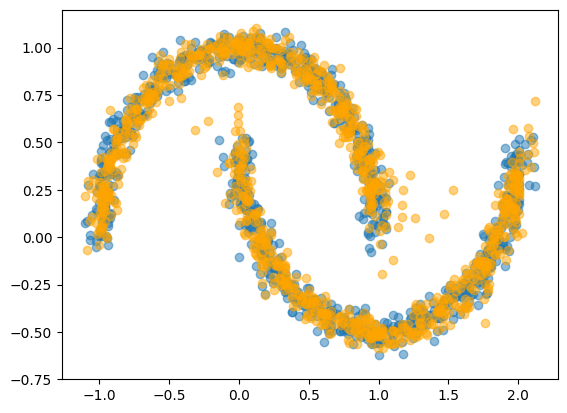

In [12]:
def gmm_loss(mean, std, weights, ys):
    normals = torch.distributions.Normal(mean, std)
    
    log_probs = normals.log_prob(ys)
    log_probs = log_probs + torch.log(weights)
    log_probs = torch.logsumexp(log_probs, dim=1)
    
    loss = -log_probs.mean()

    return loss

model = MDN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X_moons, _ = make_moons(n_samples=1000, noise=0.05, random_state=42)
x_moons = torch.tensor(X_moons[:, 0]).float().unsqueeze(1)
y_moons = torch.tensor(X_moons[:, 1]).float().unsqueeze(1)

for epoch in range(500):
    mean, std, weights = model(x_moons)

    loss = gmm_loss(mean, std, weights, y_moons)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

plt.ylim(-0.75, 1.2)
plt.plot(x_moons, model.sample(x_moons.view(-1, 1))[0], 'o', alpha=0.5, color='orange')
plt.scatter(x=x_moons, y=y_moons, alpha=0.5);